In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [2]:
print(sns.get_dataset_names())

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [3]:
df = sns.load_dataset('flights')
df.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [4]:
df.year.unique()

array([1949, 1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959,
       1960])

In [5]:
df.month.unique()

['Jan', 'Feb', 'Mar', 'Apr', 'May', ..., 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
Length: 12
Categories (12, str): ['Jan', 'Feb', 'Mar', 'Apr', ..., 'Sep', 'Oct', 'Nov', 'Dec']

In [6]:
df.passengers.unique()

array([112, 118, 132, 129, 121, 135, 148, 136, 119, 104, 115, 126, 141,
       125, 149, 170, 158, 133, 114, 140, 145, 150, 178, 163, 172, 199,
       184, 162, 146, 166, 171, 180, 193, 181, 183, 218, 230, 242, 209,
       191, 194, 196, 236, 235, 229, 243, 264, 272, 237, 211, 201, 204,
       188, 227, 234, 302, 293, 259, 203, 233, 267, 269, 270, 315, 364,
       347, 312, 274, 278, 284, 277, 317, 313, 318, 374, 413, 405, 355,
       306, 271, 301, 356, 348, 422, 465, 467, 404, 305, 336, 340, 362,
       363, 435, 491, 505, 359, 310, 337, 360, 342, 406, 396, 420, 472,
       548, 559, 463, 407, 417, 391, 419, 461, 535, 622, 606, 508, 390,
       432])

In [7]:
df.shape

(144, 3)

In [9]:
x = df['month']

In [10]:
df = df.drop(columns=['month'])
df.head()

,year,passengers
0,1949,112
1,1949,118
2,1949,132
3,1949,129
4,1949,121


In [11]:
from sklearn.cluster import KMeans
kmean = KMeans(n_clusters=3)
label = kmean.fit_predict(df)
df['cluster'] = label
df.head()

,year,passengers,cluster
0,1949,112,1
1,1949,118,1
2,1949,132,1
3,1949,129,1
4,1949,121,1


In [12]:
df.cluster.unique()

array([1, 0, 2], dtype=int32)

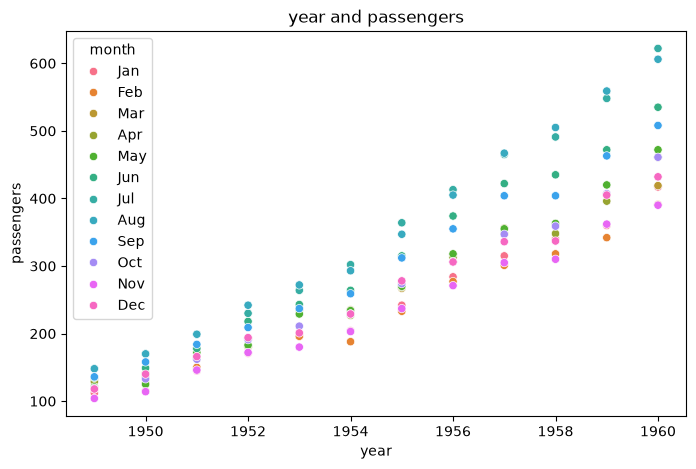

In [13]:
plt.figure(figsize=(8,5))
sns.scatterplot(x= 'year',y= 'passengers', data= df, hue= x)
plt.title('year and passengers')
plt.show()

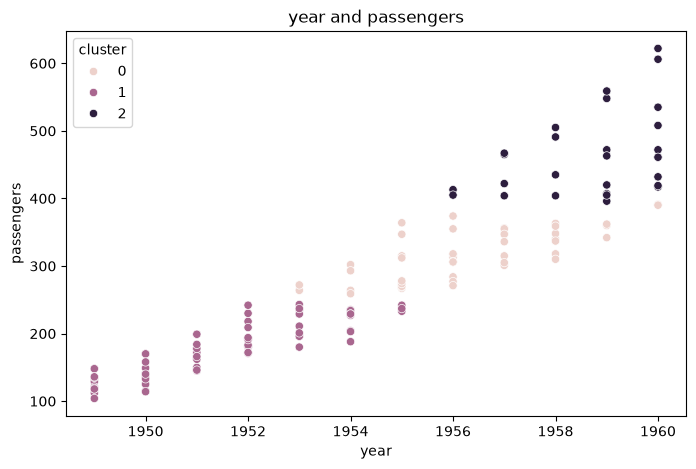

In [14]:
plt.figure(figsize=(8,5))
sns.scatterplot(x= 'year',y= 'passengers', data= df, hue= 'cluster')
plt.title('year and passengers')
plt.show()

In [17]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps= 0.5,min_samples= 5)
df['dbscan'] = dbscan.fit_predict(df[['passengers','year']])
df.head()

,year,passengers,cluster,dbscan
0,1949,112,1,-1
1,1949,118,1,-1
2,1949,132,1,-1
3,1949,129,1,-1
4,1949,121,1,-1


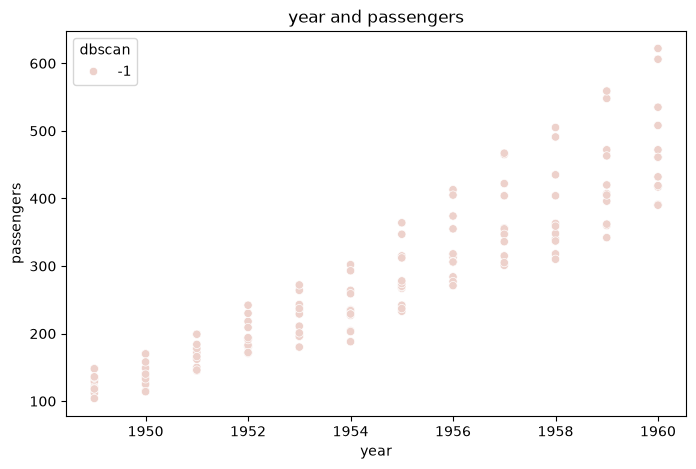

In [18]:
plt.figure(figsize=(8,5))
sns.scatterplot(x= 'year',y= 'passengers', data= df, hue= 'dbscan')
plt.title('year and passengers')
plt.show()

In [19]:
df.dbscan.unique()

array([-1])